# Global Retail Pulse — Exploratory Data Analysis

This notebook explores the cleaned sales data of a UK-based online retailer covering the period from December 2010 to December 2011. The goal is to answer key business questions about revenue trends, top-performing products, high-value customers, customer segmentation, and market performance across countries, in order to inform the retention and growth strategy presented in the accompanying Tableau dashboard.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("../data/processed/")

orders = pd.read_parquet(DATA_DIR / "orders.parquet")
monthly_aggregates = pd.read_parquet(DATA_DIR / "monthly_aggregates.parquet")
rfm = pd.read_parquet(DATA_DIR / "rfm.parquet")

print("orders shape:", orders.shape)
display(orders.head(3))

print("monthly_aggregates shape:", monthly_aggregates.shape)
display(monthly_aggregates.head(3))

print("rfm shape:", rfm.shape)
display(rfm.head(3))

orders shape: (524878, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850,United Kingdom,22.00


monthly_aggregates shape: (13, 4)


,year_month,total_revenue,total_orders,unique_customers
0,2010-12,821452.73,1559,885
1,2011-01,689811.61,1086,741
2,2011-02,522545.56,1100,758


rfm shape: (4338, 5)


,Customer ID,recency,frequency,monetary,segment
0,12346,326,1,77183.60,Lost
1,12347,3,7,4310.00,Loyal
2,12348,76,4,1797.24,New


## 1. Monthly Revenue Trend
*Business question: What are the overall revenue and order volume trends over time?*

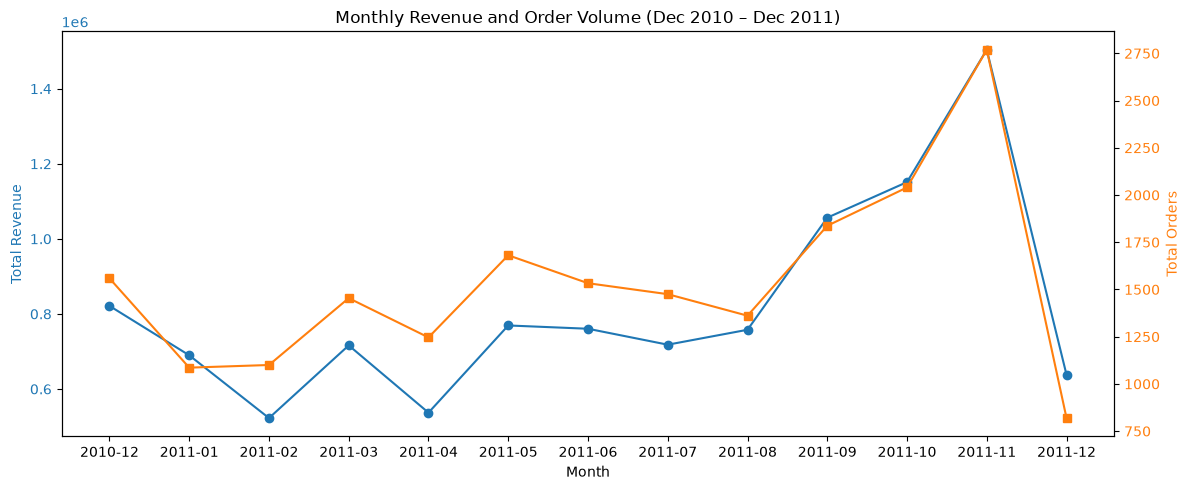

In [2]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly_aggregates["year_month"], monthly_aggregates["total_revenue"], color="tab:blue", marker="o", label="Total Revenue")
ax1.set_xlabel("Month")
ax1.set_ylabel("Total Revenue", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(monthly_aggregates["year_month"], monthly_aggregates["total_orders"], color="tab:orange", marker="s", label="Total Orders")
ax2.set_ylabel("Total Orders", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Monthly Revenue and Order Volume (Dec 2010 – Dec 2011)")
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

Revenue and order volume move together throughout the year and both show a clear seasonal lift heading into Q4, peaking in November as customers stock up ahead of the holidays. December looks like a sharp drop-off, but that's because the dataset only covers the first few days of that month rather than a true decline in demand. Overall, the business shows healthy, fairly stable month-to-month performance outside of the holiday spike.

## 2. Top 10 Products by Revenue
*Business question: Which products drive the most revenue?*

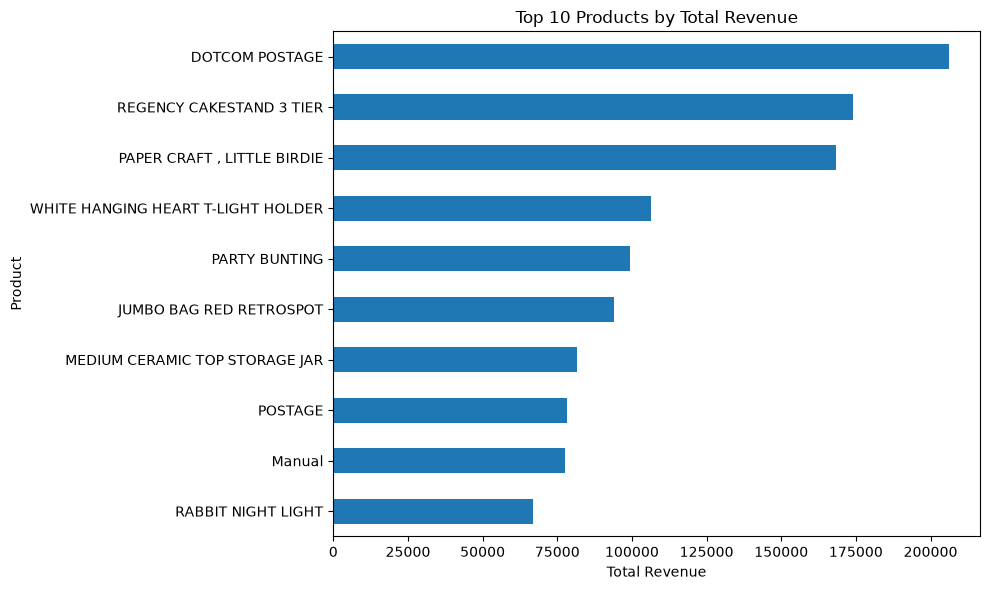

In [3]:
top_products = orders.groupby("Description")["revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

A small handful of products account for a disproportionate share of total revenue, suggesting the catalog has a clear set of "hero" items worth prioritizing in marketing and inventory planning. Ensuring these top sellers stay in stock and well promoted likely has an outsized impact on overall revenue.

## 3. Top 10 Customers by Revenue
*Business question: Who are the highest-value customers?*

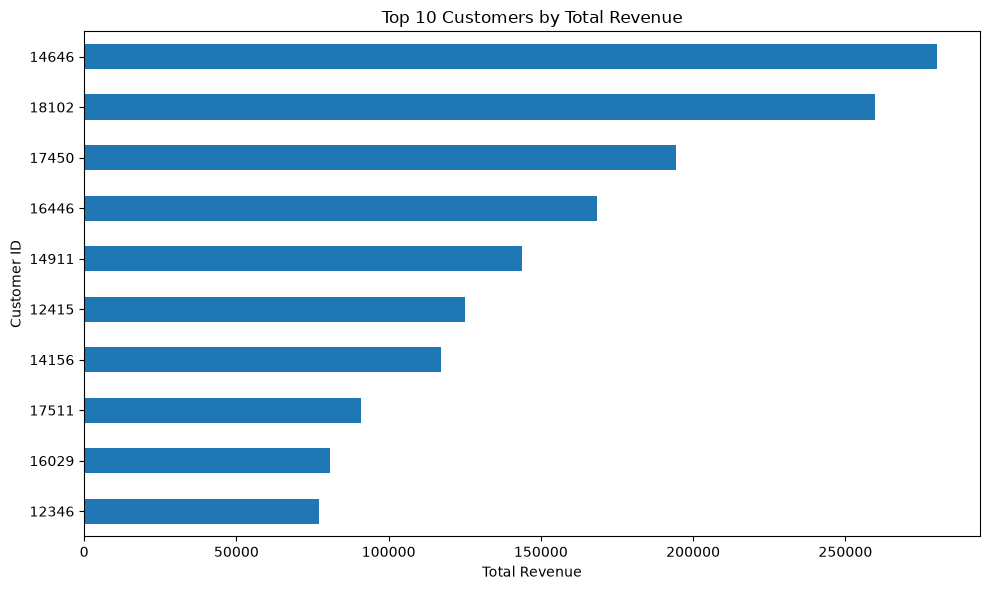

In [4]:
known_customers = orders[orders["Customer ID"] != "Guest"]
top_customers = known_customers.groupby("Customer ID")["revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_customers.sort_values().plot(kind="barh")
plt.title("Top 10 Customers by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

Revenue is heavily concentrated among a small group of top customers, each contributing far more than the average buyer. This represents a clear retention opportunity — losing even one of these accounts would have a meaningful impact on revenue, so they should be prioritized for loyalty programs and personalized outreach.

## 4. Customer Segmentation (RFM Analysis)
*Business question: How can customers be segmented to identify retention opportunities?*

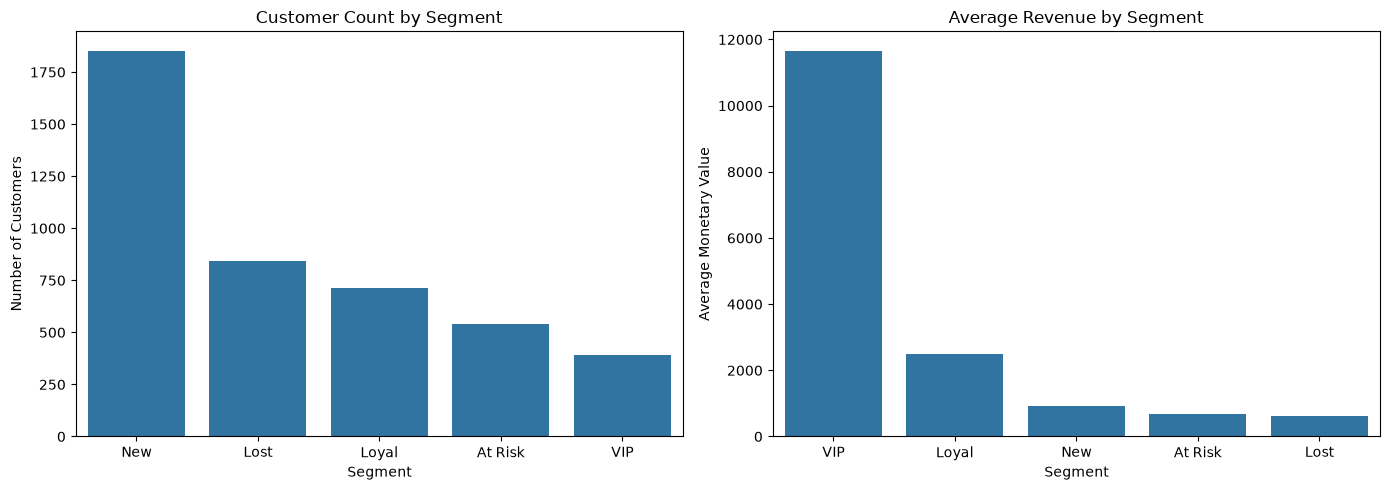

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segment_order = rfm["segment"].value_counts().index

sns.countplot(data=rfm, x="segment", order=segment_order, ax=axes[0])
axes[0].set_title("Customer Count by Segment")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Number of Customers")

avg_monetary = rfm.groupby("segment")["monetary"].mean().sort_values(ascending=False)
sns.barplot(x=avg_monetary.index, y=avg_monetary.values, ax=axes[1])
axes[1].set_title("Average Revenue by Segment")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Average Monetary Value")

plt.tight_layout()
plt.show()

VIP customers are the smallest segment by headcount but generate by far the highest average revenue per customer, confirming they are the business's most valuable asset. New customers make up the largest group, representing a growth opportunity if they can be converted into repeat buyers. At Risk customers stand out as an immediate retention priority — they have meaningful historical value but haven't purchased recently, making them strong candidates for targeted win-back campaigns before they churn entirely.

## 5. Sales Performance by Country
*Business question: How does sales performance vary by country?*

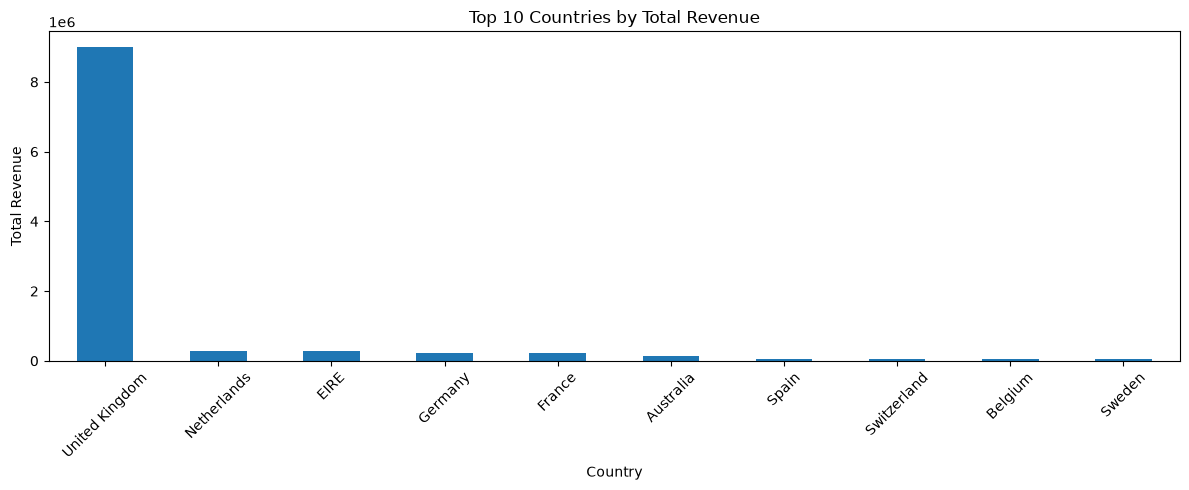

In [6]:
top_countries = orders.groupby("Country")["revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_countries.plot(kind="bar")
plt.title("Top 10 Countries by Total Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The United Kingdom dominates total revenue by a wide margin, which makes sense given the retailer's home market and customer base. The secondary markets are much smaller individually, but together they suggest room for international expansion, particularly by doubling down on the next tier of countries already generating meaningful revenue.

## 6. Export Summary Tables for Tableau Dashboard

In [7]:
monthly_aggregates.to_csv(DATA_DIR / "tableau_monthly.csv", index=False)
print("Saved tableau_monthly.csv")

top_products_export = (
    orders.groupby("Description")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
    .rename(columns={"revenue": "total_revenue"})
)
top_products_export.to_csv(DATA_DIR / "tableau_top_products.csv", index=False)
print("Saved tableau_top_products.csv")

rfm.to_csv(DATA_DIR / "tableau_rfm.csv", index=False)
print("Saved tableau_rfm.csv")

country_export = (
    orders.groupby("Country")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"revenue": "total_revenue"})
)
country_export.to_csv(DATA_DIR / "tableau_country.csv", index=False)
print("Saved tableau_country.csv")

Saved tableau_monthly.csv
Saved tableau_top_products.csv
Saved tableau_rfm.csv
Saved tableau_country.csv
